# Differentiable Likelihood

_Author: Hidde T. Jense_

In this notebook, we look at some differentiable properties of the JAX likelihood.

I will show how to:
- Compute gradients and Hessians,
- Use a differentiable optimizer to find the best-fitting foreground (for constant cosmology).

In [67]:
import jax
from jax import numpy as jnp
from jax import scipy as jsc

import numpy as np
import matplotlib.pyplot as plt

import camb

import sys
sys.path.insert(0, "../")

import mflike_jax

import pprint

try:
    from tqdm.notebook import tqdm
except:
    tqdm = lambda x: x

In [68]:
import matplotlib.patches as mpt
import matplotlib.transforms as mtr

def add_ellipse(ax, m, s, cov, nstd=1., **kwargs):
    R = cov / (s[0] * s[1])
    erx = np.sqrt(1. + R)
    ery = np.sqrt(1. - R)

    ell = mpt.Ellipse((0, 0), width=2*erx, height=2*ery, **kwargs)
    mx, my = m
    sx, sy = s

    tf = mtr.Affine2D().rotate_deg(45).scale(nstd*sx, nstd*sy).translate(mx, my)
    ell.set_transform(tf + ax.transData)
    ax.add_patch(ell)

In [69]:
like = mflike_jax.MFLike_jax("../act_dr6.yaml")
fg_model = mflike_jax.BandpowerForegrounds("../act_dr6_foregrounds.yaml", like)

cosmo_params = {
    "ombh2": 0.0225,
    "omch2": 0.1193,
    "cosmomc_theta": 104.073e-4,
    "ns": 0.9709,
    "logA": 3.056,
    "tau": 0.0603
}

cosmo_params["As"] = 1e-10 * np.exp(cosmo_params.pop("logA"))

pars = camb.set_params(lens_potential_accuracy=8, lmax=8500, **cosmo_params)
res = camb.get_results(pars)
spec = res.get_cmb_power_spectra(CMB_unit="muK")["total"]

Assuming data rows are in the correct order as it was before version 1.0.


In [70]:
# Some of our parameters have external priors, for example map-level calibration priors.
# We define these here:
priors = {
    "calG_all": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.003),

    # This prior doesn't appear in MFLike, but as pa4_f220 doesn't contain any polarization data,
    # I add it here to keep it well-behaved when taking derivatives of the log-posterior!
    "calE_dr6_pa4_f220": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.01),

    "cal_dr6_pa4_f220": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.013),
    "cal_dr6_pa5_f090": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0016),
    "cal_dr6_pa5_f150": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0020),
    "cal_dr6_pa6_f090": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0018),
    "cal_dr6_pa6_f150": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0024),

    "bandint_shift_dr6_pa4_f220": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=3.6),
    "bandint_shift_dr6_pa5_f090": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.0),
    "bandint_shift_dr6_pa5_f150": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.3),
    "bandint_shift_dr6_pa6_f090": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.2),
    "bandint_shift_dr6_pa6_f150": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.1),

    "a_gtt": lambda x: jsc.stats.norm.logpdf(x, loc=7.95, scale=0.32),
    "a_gte": lambda x: jsc.stats.norm.logpdf(x, loc=0.432, scale=0.03),
    "a_gee": lambda x: jsc.stats.norm.logpdf(x, loc=0.1681, scale=0.017),
}

# All of these priors are simple Gaussians.

In [71]:
# JAX can compute derivatives for you using automatic differentiation.
# Let's define a simple log-posterior function:

parameters = like.parameters + fg_model.parameters

def logpost(theta):
    # First, we need a prior contribution.
    # We use the list of named parameters defined above to find the index of each parameter in the vector.
    logprior = jnp.sum(jnp.array([
        priors[p](theta[parameters.index(p)]) for p in priors
    ]))

    # We need to split the parameter vectors into the likelihood and foreground parts.
    theta_like = theta[:len(like.parameters)]
    theta_fg = theta[len(like.parameters):]

    # Then we need a likelihood contribution.
    foregrounds = fg_model.get_foreground_model(theta_fg)
    loglike = -0.5 * like.chisquare(spec[:,0], spec[:,3], spec[:,1], foregrounds, theta_like)

    return logprior + loglike

In [72]:
# Similar to the previous notebook's example, we can evaluate this function:
parameter_values = {
    "a_tSZ": 3.4,
    "alpha_tSZ": -0.5,
    "a_kSZ": 1.5,
    "a_c": 3.7,
    "a_p": 7.7,
    "beta_p": 1.9,
    "beta_c": 1.9,
    "xi": 0.09,
    "a_s": 2.9,
    "beta_s": -2.8,
    "a_pste": -0.025,
    "a_psee": 0.02,

    "a_gtt": 7.95,
    "a_gte": 0.423,
    "a_gee": 0.1681,

    "alpha_dT": -0.6,
    "alpha_dE": -0.4,
    "alpha_s": 1.0,
    "T_effd": 19.6,
    "T_d": 9.7,
    "beta_d": 1.5,
    "alpha_p": 1.0,
    "alpha_c": 0.8,

    "calG_all": 1.0,

    "cal_dr6_pa4_f220": 0.98,
    "cal_dr6_pa5_f090": 1.0,
    "cal_dr6_pa5_f150": 1.0,
    "cal_dr6_pa6_f090": 1.0,
    "cal_dr6_pa6_f150": 1.0,

    "calE_dr6_pa4_f220": 1.0,
    "calE_dr6_pa5_f090": 0.985,
    "calE_dr6_pa5_f150": 0.995,
    "calE_dr6_pa6_f090": 1.00,
    "calE_dr6_pa6_f150": 0.995,

    "bandint_shift_dr6_pa4_f220": 5.0,
    "bandint_shift_dr6_pa5_f090": 0.0,
    "bandint_shift_dr6_pa5_f150": -1.0,
    "bandint_shift_dr6_pa6_f090": 1.0,
    "bandint_shift_dr6_pa6_f150": 0.0,
}

theta = jnp.array([ parameter_values[p] for p in parameters ])

logp = logpost(theta)
print(f"log(post) = {logp:.2f}")
# Note that our log prior function is not properly normalized, so this value by itself is not super meaningful.

log(post) = -811.63


In [73]:
# Now, we can ask JAX to compute a gradient for us:
logpost_grad = jax.grad(logpost)

# It really is as simple as that!
# Now, let's see in which direction our log-posterior changes:
grad_theta = logpost_grad(theta)

for i, p in enumerate(parameters):
    print(f"d log(post) / d {p:<30s} = {grad_theta[i]:+.3e}")

d log(post) / d calG_all                       = +1.613e+03
d log(post) / d cal_dr6_pa4_f220               = -8.765e+02
d log(post) / d calE_dr6_pa4_f220              = +0.000e+00
d log(post) / d cal_dr6_pa5_f090               = +3.228e+03
d log(post) / d calE_dr6_pa5_f090              = +8.547e+02
d log(post) / d cal_dr6_pa5_f150               = -2.494e+03
d log(post) / d calE_dr6_pa5_f150              = +6.536e+02
d log(post) / d cal_dr6_pa6_f090               = -1.321e+03
d log(post) / d calE_dr6_pa6_f090              = -2.014e+02
d log(post) / d cal_dr6_pa6_f150               = +3.175e+03
d log(post) / d calE_dr6_pa6_f150              = +1.281e+03
d log(post) / d bandint_shift_dr6_pa4_f220     = +1.107e+01
d log(post) / d bandint_shift_dr6_pa5_f090     = +2.727e+01
d log(post) / d bandint_shift_dr6_pa5_f150     = +3.454e+00
d log(post) / d bandint_shift_dr6_pa6_f090     = +1.376e+01
d log(post) / d bandint_shift_dr6_pa6_f150     = -5.470e-02
d log(post) / d a_kSZ                   

In [74]:
# We can also ask JAX to compute the second order derivative (Hessian matrix) for us:
logpost_hess = jax.hessian(logpost)
H = logpost_hess(theta)

print(H)

[[-2.2440120e+06 -1.3570148e+05  0.0000000e+00 ...  7.3932385e+02
   1.1521791e+04  5.5657734e+03]
 [-1.3570152e+05 -1.4915766e+05  0.0000000e+00 ... -1.6104907e+00
  -8.5048843e+01 -1.3380313e+01]
 [ 0.0000000e+00  0.0000000e+00 -1.0000000e+04 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 ...
 [ 7.3932373e+02 -1.6104906e+00  0.0000000e+00 ... -2.8075064e+01
  -4.3782745e+01 -4.0736397e+01]
 [ 1.1521792e+04 -8.5048859e+01  0.0000000e+00 ... -4.3782734e+01
  -3.8988616e+03 -1.5909296e+02]
 [ 5.5657725e+03 -1.3380318e+01  0.0000000e+00 ... -4.0736393e+01
  -1.5909293e+02 -3.5861738e+03]]


In [75]:
# Here, we now implement Newton-Raphson to maximize the function.
def newt_raph_step(x, grad, hess):
    return x - 1e-1 * jnp.linalg.solve(hess(x), -grad(x))

x = theta
trace = [x]

for _ in tqdm(range(25)):
    x = newt_raph_step(x, logpost_grad, logpost_hess)
    if jnp.any(jnp.isnan(x)):
        break
    trace.append(x)

  0%|          | 0/25 [00:00<?, ?it/s]

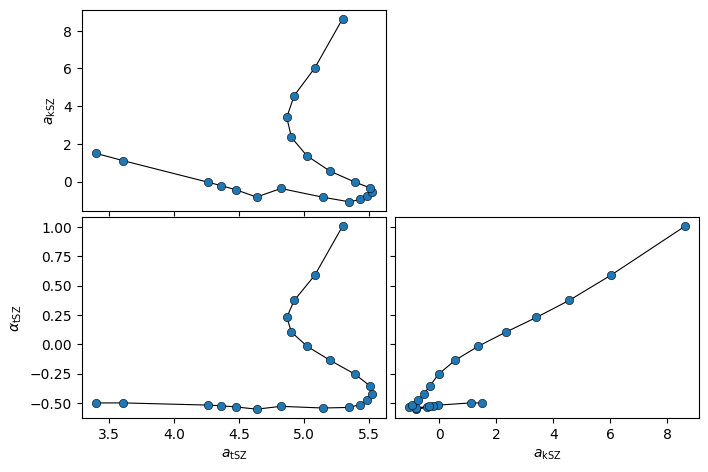

In [76]:
chain = np.array(trace)

params = ["a_tSZ", "a_kSZ", "alpha_tSZ"]
labels = [r"a_{\rm tSZ}", r"a_{\rm kSZ}", r"\alpha_{\rm tSZ}"]

fig, axes = plt.subplots(len(params), len(params), sharex="col", sharey="row", figsize = (12, 8), gridspec_kw={"hspace":0.03, "wspace":0.03})

for i, ipar in enumerate(params):
    for j, jpar in enumerate(params):
        ax = axes[i,j]
        if j >= i:
            fig.delaxes(ax)
            continue

        xpar = parameters.index(ipar)
        ypar = parameters.index(jpar)
        x = chain[:, xpar]
        y = chain[:, ypar]

        ax.plot(y, x, color="k", linewidth=0.8, marker="o", markerfacecolor="C0", markeredgewidth=0.4)

        if j == 0:
            ax.set_ylabel(f"${labels[i]}$")
        if i == len(params)-1:
            ax.set_xlabel(f"${labels[j]}$")

In [77]:
# Now, this worked somewhat, but straightforward minimizers are not optimal for this method.
# Luckily, smarter people have implemented better methods. Here we explore the Adam minimizer from Optax.
import optax

# Annoyingly, these optimizers are all looking for minima, whereas our function has a maximum.
# Hence we need to redefine our logposterior to include a minus sign:
def logpost_adam(theta):
    # Add a minus sign
    return -logpost(theta)

grad_adam = jax.grad(logpost_adam)
hess_adam = jax.hessian(logpost_adam)

In [78]:
import random

# To make it more fun, we'll start at a random point near the best-fit.

random_point = {
    "a_tSZ": random.gauss(3.4, 0.3),
    "alpha_tSZ": random.gauss(-0.5, 0.1),
    "a_kSZ": random.gauss(1.5, 0.3),
    "a_c": random.gauss(3.7, 0.5),
    "a_p": random.gauss(7.7, 1.0),
    "beta_p": random.gauss(1.9, 0.2),
    "beta_c": random.gauss(1.9, 0.2),
    "xi": random.uniform(0.01, 0.19),
    "a_s": random.gauss(2.9, 0.3),
    "beta_s": random.gauss(-2.8, 0.2),
    "a_pste": random.gauss(0.0, 0.01),
    "a_psee": random.uniform(0.01, 0.09),

    "a_gtt": random.gauss(7.95, 0.3),
    "a_gte": random.gauss(0.423, 0.03),
    "a_gee": random.gauss(0.1681, 0.03),

    "alpha_dT": -0.6,
    "alpha_dE": -0.4,
    "alpha_s": 1.0,
    "T_effd": 19.6,
    "T_d": 9.7,
    "beta_d": 1.5,
    "alpha_p": 1.0,
    "alpha_c": 0.8,

    "calG_all": 1.0,

    "cal_dr6_pa4_f220": 1.0,
    "cal_dr6_pa5_f090": 1.0,
    "cal_dr6_pa5_f150": 1.0,
    "cal_dr6_pa6_f090": 1.0,
    "cal_dr6_pa6_f150": 1.0,

    "calE_dr6_pa4_f220": 1.0,
    "calE_dr6_pa5_f090": 1.0,
    "calE_dr6_pa5_f150": 1.0,
    "calE_dr6_pa6_f090": 1.0,
    "calE_dr6_pa6_f150": 1.0,

    "bandint_shift_dr6_pa4_f220": 0.0,
    "bandint_shift_dr6_pa5_f090": 0.0,
    "bandint_shift_dr6_pa5_f150": 0.0,
    "bandint_shift_dr6_pa6_f090": 0.0,
    "bandint_shift_dr6_pa6_f150": 0.0,
}

theta = jnp.array([ random_point[p] for p in parameters ])

In [79]:
optimizer = optax.adam(learning_rate=1e-1)
opt_state = optimizer.init(theta)

x_adam = theta.copy()
chain_adam = [x_adam]

for _ in tqdm(range(100)):
    updates, opt_state = optimizer.update(grad_adam(x_adam), opt_state, params)
    x_adam = optax.apply_updates(x_adam, updates)
    chain_adam.append(x_adam)

chain_adam = np.array(chain_adam)

  0%|          | 0/100 [00:00<?, ?it/s]

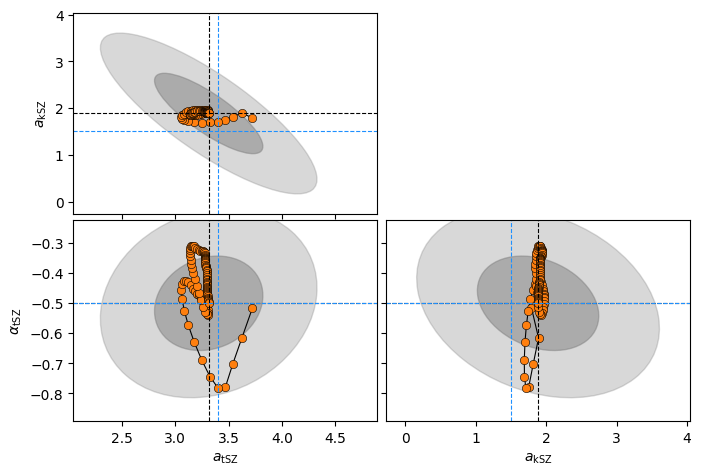

In [80]:
params = ["a_tSZ", "a_kSZ", "alpha_tSZ"]
labels = [r"a_{\rm tSZ}", r"a_{\rm kSZ}", r"\alpha_{\rm tSZ}"]

H = hess_adam(x_adam)
F = jnp.linalg.inv(H)
err = jnp.sqrt(jnp.diag(F))

# Here we plot the final chain.
# - in orange, we show the samples found using Optax.
# - in grey, we show the Fisher information matrix (which is a reasonable estimate of the posterior)
# - in blue, we show the Louis et al (2025) best-fitting parameters, and in black we show our own.

# Note that we have different degrees of freedom from Louis et al., notably we are not fitting for the Cosmology here, but we are including many additional foreground parameters.
# One could rewrite the logposterior function to keep the same parameters fixed as in Louis et al. before, and only fit for the same foregrounds.

fig, axes = plt.subplots(len(params), len(params), sharex="col", sharey="row", figsize = (12, 8), gridspec_kw={"hspace":0.03, "wspace":0.03})

for i, ipar in enumerate(params):
    for j, jpar in enumerate(params):
        ax = axes[i,j]
        if j >= i:
            fig.delaxes(ax)
            continue

        xpar = parameters.index(ipar)
        ypar = parameters.index(jpar)
        x = chain_adam[:, xpar]
        y = chain_adam[:, ypar]

        ax.plot(y, x, color="k", linewidth=0.8, marker="o", markerfacecolor="C1", markeredgewidth=0.4)
        ax.axvline(y[-1], c="k", lw=0.8, ls="--")
        ax.axhline(x[-1], c="k", lw=0.8, ls="--")

        ax.axvline(parameter_values[jpar], c="dodgerblue", lw=0.8, ls="--")
        ax.axhline(parameter_values[ipar], c="dodgerblue", lw=0.8, ls="--")

        add_ellipse(ax, [y[-1], x[-1]], [err[ypar], err[xpar]], F[xpar,ypar], nstd=1., color="grey", alpha=0.5)
        add_ellipse(ax, [y[-1], x[-1]], [err[ypar], err[xpar]], F[xpar,ypar], nstd=2., color="grey", alpha=0.3)

        ax.set_xlim(y[-1] - 2.5 * err[ypar], y[1] + 2.5 * err[ypar])
        ax.set_ylim(x[-1] - 2.5 * err[xpar], x[1] + 2.5 * err[xpar])

        if j == 0:
            ax.set_ylabel(f"${labels[i]}$")
        if i == len(params)-1:
            ax.set_xlabel(f"${labels[j]}$")